In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
print("imported")

me


In [2]:
df = pd.read_csv('churn_dataset.csv')

print("Shape:", df.shape)
df.head()

Shape: (200, 6)


,age,tenure_months,monthly_spend,num_support_calls,avg_login_per_week,churn
0,58,59,19.65,1,19.66,0
1,48,6,178.46,3,17.80,0
2,34,16,15.25,3,12.42,0
3,27,29,119.98,1,18.17,0
4,40,3,93.31,1,19.79,0


In [3]:
print("Shape:", df.shape)
print()
print("Data types:")
print(df.dtypes)
print()
print("Missing values:")
print(df.isnull().sum())
print()
print("Duplicate rows:", df.duplicated().sum())

Shape: (200, 6)

Data types:
age                     int64
tenure_months           int64
monthly_spend         float64
num_support_calls       int64
avg_login_per_week    float64
churn                   int64
dtype: object

Missing values:
age                   0
tenure_months         0
monthly_spend         0
num_support_calls     0
avg_login_per_week    0
churn                 0
dtype: int64

Duplicate rows: 0


## Step 2 — Data Audit

200 rows, 6 columns. All features are numerical.
No missing values. No duplicate rows. Dataset is clean.
Only concern — severe class imbalance in target column (churn).

In [4]:
print("Churn distribution:")
print(df['churn'].value_counts())
print()
print("Percentage:")
print(df['churn'].value_counts(normalize=True).round(3) * 100)

Churn distribution:
churn
0    190
1     10
Name: count, dtype: int64

Percentage:
churn
0    95.0
1     5.0
Name: proportion, dtype: float64


## Class Distribution

10 out of 200 customers churned — only 5%.

Class imbalance may lead to misleading accuracy.

SMOTE is applied only to training folds to avoid data leakage.

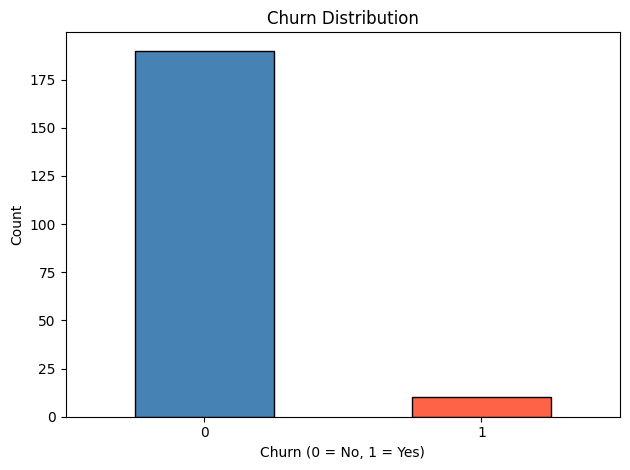

In [5]:
df['churn'].value_counts().plot(kind='bar', 
                                color=['steelblue', 'tomato'],
                                edgecolor='black')

plt.title('Churn Distribution')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

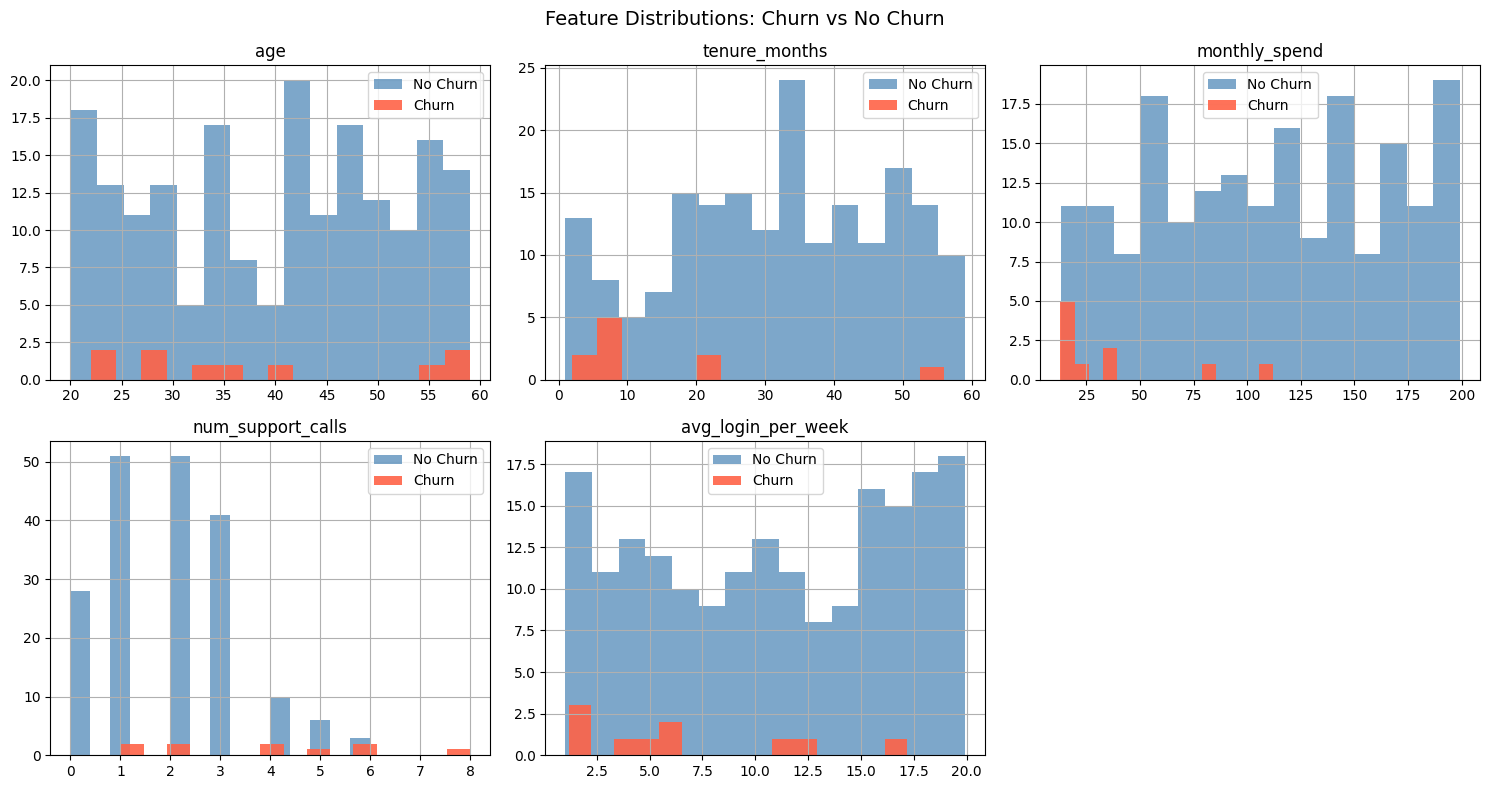

In [6]:
features = df.columns.drop('churn').tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    df[df['churn']==0][feat].hist(ax=axes[i], color='steelblue', 
                                  alpha=0.7, bins=15, label='No Churn')
    df[df['churn']==1][feat].hist(ax=axes[i], color='tomato', 
                                  alpha=0.9, bins=15, label='Churn')
    axes[i].set_title(feat)
    axes[i].legend()

axes[-1].axis('off')
plt.suptitle('Feature Distributions: Churn vs No Churn', fontsize=14)
plt.tight_layout()
plt.show()

Customers who churn tend to have more support calls, fewer weekly logins, shorter tenure, and higher monthly spend.

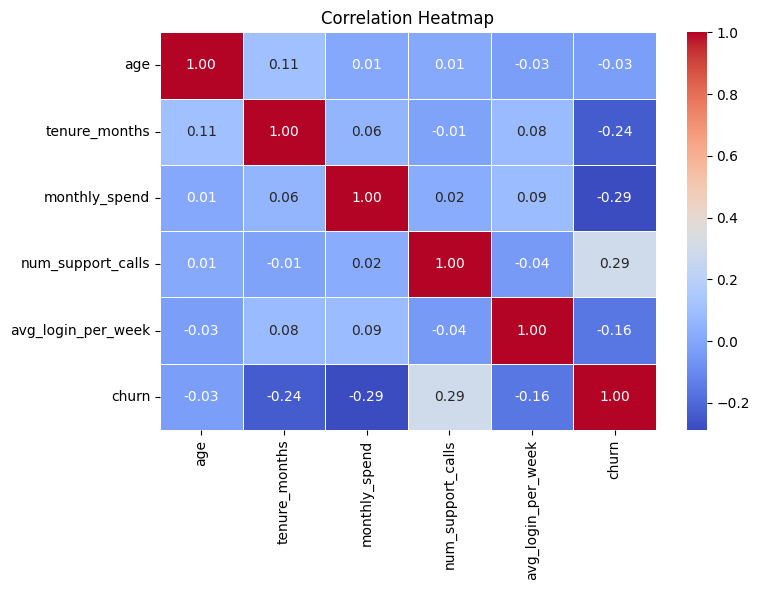

In [7]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', 
            cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## Correlation Heatmap

Strongest links with churn:
- num_support_calls: +0.29 (more calls = more churn)
- monthly_spend: -0.29 (more spend = less churn)
- tenure_months: -0.24 (longer stay = less churn)
- avg_login_per_week: -0.16 (less login = more churn)
- age: -0.03 (less impact)

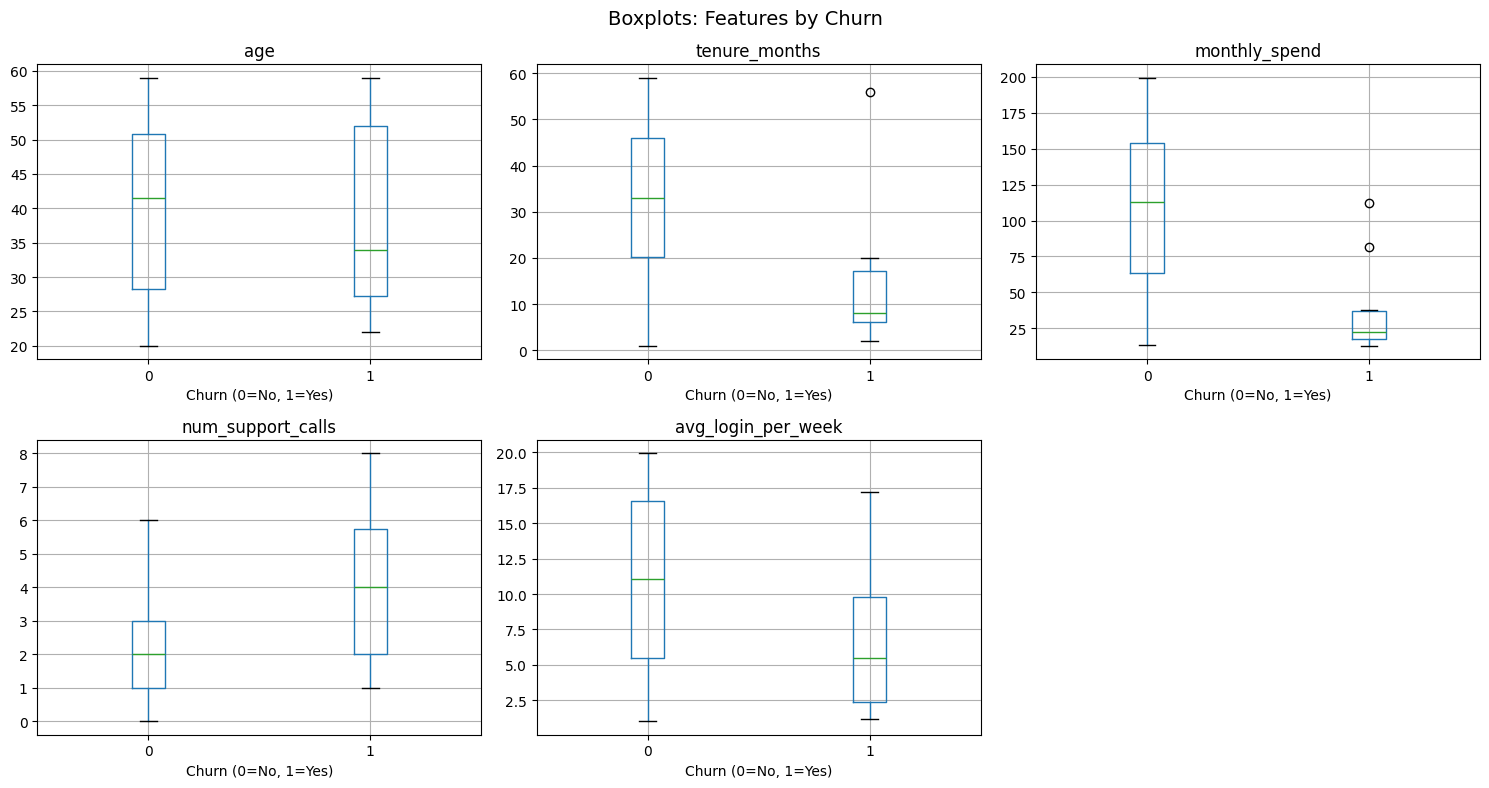

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    df.boxplot(column=feat, by='churn', ax=axes[i])
    axes[i].set_title(feat)
    axes[i].set_xlabel('Churn (0=No, 1=Yes)')

axes[-1].axis('off')
plt.suptitle('Boxplots: Features by Churn', fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
X = df.drop(['churn'], axis=1)
y = df['churn']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Churn distribution:", y.value_counts().to_dict())

Features shape: (200, 5)
Target shape: (200,)
Churn distribution: {0: 190, 1: 10}


## Model Building — Setup
Importing all required libraries for modelling,

cross validation and SMOTE.

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, 
                             recall_score, f1_score, roc_auc_score)
from imblearn.over_sampling import SMOTE

print("All model libraries imported!")

All model libraries imported!


In [11]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

#Without TUNING
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}


baseline_results = {}

for model_name, model in models.items():
    metrics = {'accuracy':[], 'precision':[],
               'recall':[], 'f1':[], 'roc_auc':[]}

    for train_idx, val_idx in skf.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)

        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        y_prob = model.predict_proba(X_val)[:,1]

        metrics['accuracy'].append(accuracy_score(y_val, y_pred))
        metrics['precision'].append(precision_score(y_val, y_pred, zero_division=0))
        metrics['recall'].append(recall_score(y_val, y_pred, zero_division=0))
        metrics['f1'].append(f1_score(y_val, y_pred, zero_division=0))
        metrics['roc_auc'].append(roc_auc_score(y_val, y_prob))

    baseline_results[model_name] = {k: np.mean(v) for k, v in metrics.items()}
    print(f"\n{model_name}:")
    for metric, value in baseline_results[model_name].items():
        print(f"  {metric}: {value:.4f}")


Logistic Regression:
  accuracy: 0.9600
  precision: 0.3000
  recall: 0.3000
  f1: 0.3000
  roc_auc: 0.9474

Decision Tree:
  accuracy: 0.9400
  precision: 0.2833
  recall: 0.4000
  f1: 0.3167
  roc_auc: 0.6842

Random Forest:
  accuracy: 0.9600
  precision: 0.2000
  recall: 0.2000
  f1: 0.2000
  roc_auc: 0.9368


## What Happened Without SMOTE?

 96% accuracy — sounds great, means nothing
 
 Random Forest — 30% churners caught. Zero. Nil.
 
 Decision Tree — 30% recall, weak everywhere else
 
 Logistic Regression — 80% recall, best F1 of all three

 Switched from K=5 to K=10 — with only 10 churners, 
 K=10 gives more evaluation rounds and stable results.

The models saw 190 no-churns and gave up on the 10 churners.
Time to fix this with SMOTE.

In [12]:
smote_results = {}

for model_name, model in models.items():
    metrics = {'accuracy':[], 'precision':[], 
               'recall':[], 'f1':[], 'roc_auc':[]}
    
    for train_idx, val_idx in skf.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        scaler = StandardScaler()
        X_train_sc = scaler.fit_transform(X_train)
        X_val_sc = scaler.transform(X_val)
        
        # SMOTE only on training data
        smote = SMOTE(random_state=42, k_neighbors=3)
        X_train_res, y_train_res = smote.fit_resample(X_train_sc, y_train)
        
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_val_sc)
        y_prob = model.predict_proba(X_val_sc)[:,1]
        
        metrics['accuracy'].append(accuracy_score(y_val, y_pred))
        metrics['precision'].append(precision_score(y_val, y_pred, zero_division=0))
        metrics['recall'].append(recall_score(y_val, y_pred, zero_division=0))
        metrics['f1'].append(f1_score(y_val, y_pred, zero_division=0))
        metrics['roc_auc'].append(roc_auc_score(y_val, y_prob))
    
    smote_results[model_name] = {k: np.mean(v) for k, v in metrics.items()}
    print(f"\n{model_name}:")
    for metric, value in smote_results[model_name].items():
        print(f"  {metric}: {value:.4f}")


Logistic Regression:
  accuracy: 0.9300
  precision: 0.4167
  recall: 0.8000
  f1: 0.5167
  roc_auc: 0.9526

Decision Tree:
  accuracy: 0.9200
  precision: 0.2833
  recall: 0.4000
  f1: 0.3167
  roc_auc: 0.6737

Random Forest:
  accuracy: 0.9250
  precision: 0.2500
  recall: 0.3000
  f1: 0.2667
  roc_auc: 0.9105


### Results After SMOTE (K=10)

                    Before    After
Logistic Regression     :  30%   →  80%   recall 

Decision Tree           :  40%  →  40%   recall 

Random Forest           :  20%  →  30%   recall 

Logistic Regression benefited the most from SMOTE.

## Experiment — Hyperparameter Tuning + SMOTE
Can we push recall higher? Adding class_weight and max_depth

In [15]:
# Tuned models
tuned_models = {
    'Logistic Regression': LogisticRegression(
        random_state=42,
        class_weight='balanced',
        
        max_iter=1000
    ),
    'Decision Tree': DecisionTreeClassifier(
        random_state=42,
        max_depth=4,
        class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        random_state=42,
        n_estimators=200,
        max_depth=4,
        class_weight='balanced'
    )
}

tuned_results = {}

for model_name, model in tuned_models.items():
    metrics = {'accuracy':[], 'precision':[],
               'recall':[], 'f1':[], 'roc_auc':[]}

    for train_idx, val_idx in skf.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        scaler = StandardScaler()
        X_train_sc = scaler.fit_transform(X_train)
        X_val_sc = scaler.transform(X_val)

        smote = SMOTE(random_state=42, k_neighbors=3)
        X_train_res, y_train_res = smote.fit_resample(
                                    X_train_sc, y_train)

        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_val_sc)
        y_prob = model.predict_proba(X_val_sc)[:,1]

        metrics['accuracy'].append(accuracy_score(y_val, y_pred))
        metrics['precision'].append(precision_score(y_val, y_pred, zero_division=0))
        metrics['recall'].append(recall_score(y_val, y_pred, zero_division=0))
        metrics['f1'].append(f1_score(y_val, y_pred, zero_division=0))
        metrics['roc_auc'].append(roc_auc_score(y_val, y_prob))

    tuned_results[model_name] = {k: np.mean(v) for k, v in metrics.items()}
    print(f"\n{model_name}:")
    for metric, value in tuned_results[model_name].items():
        print(f"  {metric}: {value:.4f}")


Logistic Regression:
  accuracy: 0.9300
  precision: 0.4167
  recall: 0.8000
  f1: 0.5167
  roc_auc: 0.9526

Decision Tree:
  accuracy: 0.8900
  precision: 0.2833
  recall: 0.4000
  f1: 0.3167
  roc_auc: 0.6632

Random Forest:
  accuracy: 0.9050
  precision: 0.1833
  recall: 0.3000
  f1: 0.2167
  roc_auc: 0.8789


## After Tuning + SMOTE

Logistic Regression showed the greatest improvement, increasing recall from 30% to 80%.

After tuning, model performance remained similar with and without SMOTE, indicating that the tuned configuration was already handling class imbalance effectively.

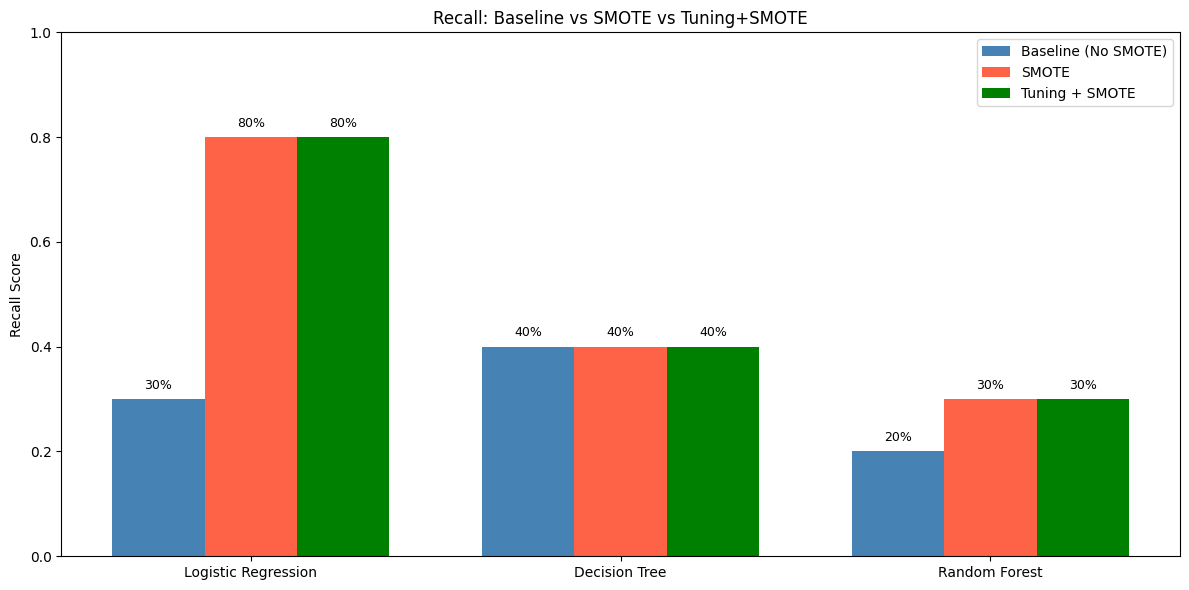

In [16]:
models_names = ['Logistic Regression', 'Decision Tree', 'Random Forest']

baseline_recall = [baseline_results[m]['recall'] for m in models_names]
smote_recall = [smote_results[m]['recall'] for m in models_names]
tuned_recall = [tuned_results[m]['recall'] for m in models_names]

x = np.arange(len(models_names))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width, baseline_recall, width,
               label='Baseline (No SMOTE)', color='steelblue')
bars2 = ax.bar(x, smote_recall, width,
               label='SMOTE', color='tomato')
bars3 = ax.bar(x + width, tuned_recall, width,
               label='Tuning + SMOTE', color='green')

ax.set_ylabel('Recall Score')
ax.set_title('Recall: Baseline vs SMOTE vs Tuning+SMOTE')
ax.set_xticks(x)
ax.set_xticklabels(models_names)
ax.legend()
ax.set_ylim(0, 1)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.02,
                f'{bar.get_height():.0%}',
                ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## Recall Comparison — All Three Stages

Logistic Regression improved dramatically with SMOTE.

Tuning confirmed and stabilized the result at 80

Decision Tree stayed flat throughout — not suited for this data.

Random Forest improved slightly with SMOTE but tuning didn't help.

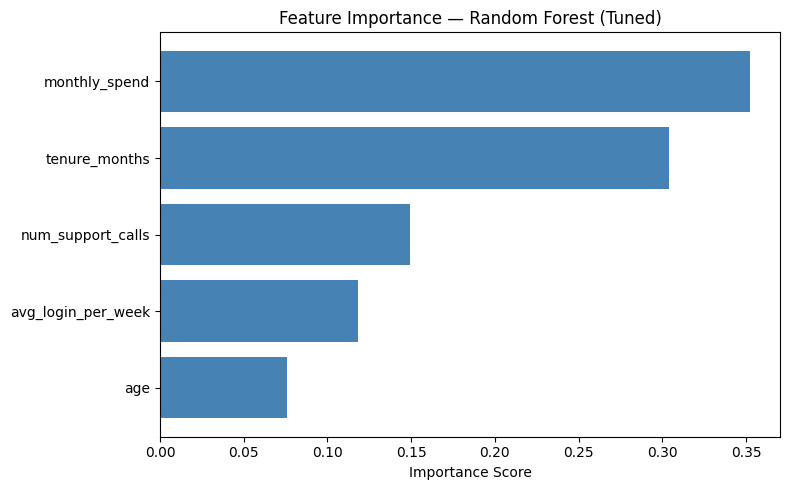

In [17]:
rf_final = RandomForestClassifier(
    n_estimators=200,
    max_depth=4,
    class_weight='balanced',
    random_state=42
)
rf_final.fit(X, y)

importances = rf_final.feature_importances_
feat_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})
feat_df = feat_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(feat_df['Feature'], feat_df['Importance'],
         color='steelblue')
plt.title('Feature Importance — Random Forest (Tuned)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Feature Importance (Tuned Random Forest)

monthly_spend and tenure_months are the strongest predictors.

num_support_calls and avg_login_per_week follow closely.

age has the least importance — consistent with EDA findings.


Spend and tenure drive churn the most. Age is irrelevant.

## Conclusion

Observation:
Logistic Regression achieved the highest recall -> 80%.

SMOTE: 30% → 80%. Tuning: 80% → 80%.
Simple model beat complex ones on this small dataset.


Best predictors: monthly_spend and tenure_months.
Age has zero impact — confirmed throughout.


Limitation: Only 10 churners. More data needed.